In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

pnl_file = (
    PROJECT_ROOT
    / "reports"
    / "daily_pnl.csv"
)

daily_pnl = pd.read_csv(
    pnl_file,
    parse_dates=["date"]
)

daily_pnl.head()

,date,portfolio_value,daily_pnl
0,2020-01-02,6.572700e+06,NaN
1,2020-01-03,6.640191e+06,67490.653436
2,2020-01-06,6.631889e+06,-8302.333993
3,2020-01-07,6.613754e+06,-18134.619967
4,2020-01-08,6.581725e+06,-32029.133654


In [2]:
daily_pnl.shape

(1495, 3)

In [3]:
daily_pnl.columns.tolist()

['date', 'portfolio_value', 'daily_pnl']

In [4]:
daily_pnl.describe()

,date,portfolio_value,daily_pnl
count,1495,1.495000e+03,1494.000000
mean,2022-12-28 15:15:03.010033,5.950638e+06,-896.425623
min,2020-01-02 00:00:00,4.745233e+06,-284663.695095
25%,2021-06-29 12:00:00,5.151982e+06,-23964.892424
50%,2022-12-28 00:00:00,5.401812e+06,-771.433932
75%,2024-06-26 12:00:00,6.828984e+06,21456.997259
max,2025-12-30 00:00:00,7.852611e+06,204337.362107
std,NaN,9.572669e+05,39851.535295


In [5]:
daily_pnl.columns.tolist()

['date', 'portfolio_value', 'daily_pnl']

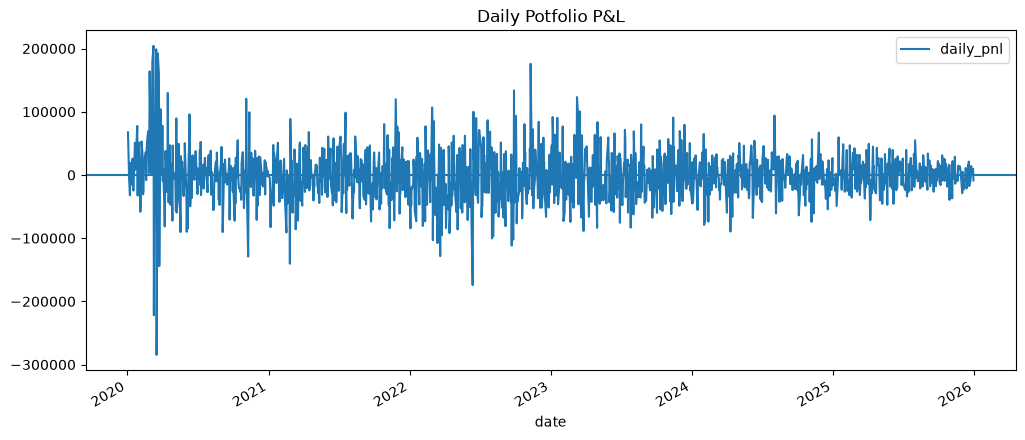

In [6]:
import matplotlib.pyplot as plt
daily_pnl.plot(x="date",y="daily_pnl",figsize=(12,5),title="Daily Potfolio P&L")
plt.axhline(0)
plt.show()

In [7]:
daily_pnl["date"] = pd.to_datetime(daily_pnl["date"])

daily_pnl["daily_pnl"] = pd.to_numeric(
    daily_pnl["daily_pnl"],
    errors="coerce"
)

daily_pnl.dtypes

date               datetime64[us]
portfolio_value           float64
daily_pnl                 float64
dtype: object

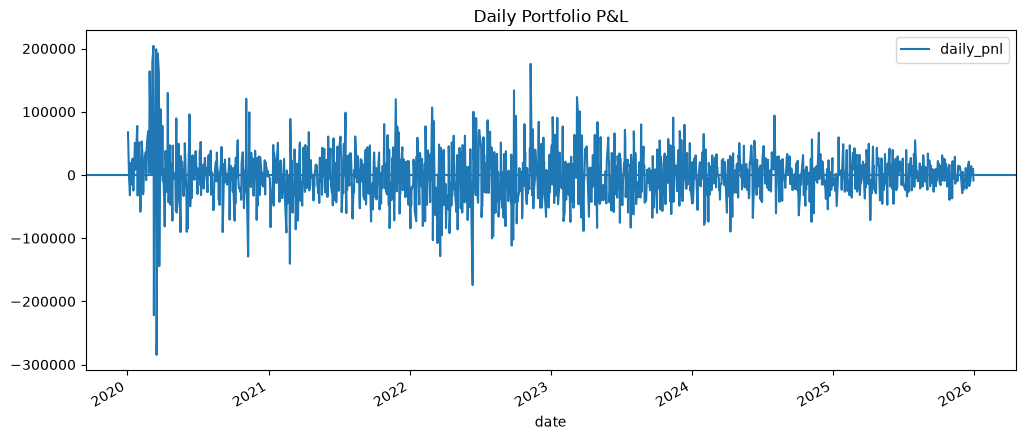

In [8]:
daily_pnl.plot(
    x="date",
    y="daily_pnl",
    figsize=(12, 5),
    title="Daily Portfolio P&L"
)

plt.axhline(0)
plt.show()

In [9]:
positive_days = (daily_pnl["daily_pnl"] > 0).sum()
negative_days = (daily_pnl["daily_pnl"] < 0).sum()
zero_days = (daily_pnl["daily_pnl"] == 0).sum()

print("Positive days:", positive_days)
print("Negative days:", negative_days)
print("Zero days:", zero_days)

Positive days: 727
Negative days: 767
Zero days: 0


In [10]:
print("Mean P&L:", daily_pnl["daily_pnl"].mean())
print("Std P&L:", daily_pnl["daily_pnl"].std())
print("Minimum P&L:", daily_pnl["daily_pnl"].min())
print("Maximum P&L:", daily_pnl["daily_pnl"].max())

Mean P&L: -896.4256229468895
Std P&L: 39851.53529510036
Minimum P&L: -284663.69509490486
Maximum P&L: 204337.36210697424
